# 01 — Datalasting og regimeklassifisering

Laster alle datakilder (2020–2026), legger til kalenderfeatures,
normaliserer med StandardScaler, og klassifiserer prisregimer.

**Output:** `intermediate/df_processed.parquet`, `intermediate/scaler.pkl`

In [1]:
import sys, os, warnings, pickle
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src import apply_style, load_all_data, add_calendar_features
from src import fit_scaler, apply_scaling, flag_negative_prices
from src import classify_regime, regime_group

apply_style()
warnings.filterwarnings("ignore")

os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports OK")
print(f"STARGATE_MW={STARGATE_MW}, STARGATE_TOTAL_MW={STARGATE_TOTAL_MW}")
print(f"TRAIN_YEARS={TRAIN_YEARS}")
print(f"TEST_YEARS={TEST_YEARS}")
print(f"Fargepalett: {PALETTE}")

Imports OK
STARGATE_MW=230, STARGATE_TOTAL_MW=520
TRAIN_YEARS=[2020, 2021, 2022, 2023]
TEST_YEARS=[2024, 2025, 2026]
Fargepalett: ['#038D7F', '#007265', '#00574C', '#003E34', '#00271E']


## 1. Datalasting

In [2]:
df = load_all_data(DATA_DIR, ALL_YEARS)

print("=" * 55)
print("DATALASTING FULLFØRT")
print("=" * 55)
print(f"Rader totalt     : {len(df):,}")
print(f"Kolonner         : {len(df.columns)}")
print(f"Periode          : {df.index.min().date()} – {df.index.max().date()}")
print(f"År representert  : {sorted(df.index.year.unique().tolist())}")
print()
print("Kolonner i df:")
for c in df.columns:
    print(f"  {c}")
print()
print("Manglende verdier per kolonne:")
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "  Ingen")

DATALASTING FULLFØRT
Rader totalt     : 53,394
Kolonner         : 28
Periode          : 2020-01-01 – 2026-02-02
År representert  : [2020, 2021, 2022, 2023, 2024, 2025, 2026]

Kolonner i df:
  price_FI
  price_NO3
  price_NO4
  price_SE1
  price_SE2
  system_price
  flow_NO4_FI
  flow_FI_NO4
  flow_NO4_NO3
  flow_NO3_NO4
  flow_NO4_SE1
  flow_SE1_NO4
  flow_NO4_SE2
  flow_SE2_NO4
  cons_FI
  cons_NO3
  cons_NO4
  cons_SE1
  prod_fossil_NO4
  prod_hydro_ror_NO4
  prod_hydro_res_NO4
  prod_other_renew_NO4
  prod_wind_NO4
  prod_total_NO4
  net_position
  fill_rate
  temp_NO4
  precip_NO4

Manglende verdier per kolonne:
temp_NO4        48
precip_NO4    1800


In [3]:
# Rask sanity-sjekk: timer per år
hours_per_year = df.groupby(df.index.year).size()
print("Timer per år:")
print(hours_per_year.to_string())
print()
print("Forventet ~8 760 per fullt år (8 784 i skuddår)")

Timer per år:
Delivery Start (CET)
2020    8783
2021    8759
2022    8759
2023    8759
2024    8783
2025    8759
2026     792

Forventet ~8 760 per fullt år (8 784 i skuddår)


In [4]:
# Kort deskriptiv oversikt
key_cols = ["price_NO4", "system_price", "cons_NO4", "fill_rate"]
df[key_cols].describe().round(1)

,price_NO4,system_price,cons_NO4,fill_rate
count,53394.0,53394.0,53394.0,53394.0
mean,244.6,616.1,2256.6,0.7
std,305.6,667.1,402.9,0.2
min,-275.8,-336.8,888.5,0.2
25%,59.4,171.7,1908.0,0.5
50%,163.4,443.8,2254.0,0.7
75%,306.0,825.5,2581.0,0.8
max,5335.1,6910.2,4211.0,1.0


## 2. Feature engineering

In [5]:
# Kalenderfeatures
df = add_calendar_features(df)
print("Kalenderfeatures lagt til:")
print(df[["hour", "month", "weekday", "season", "is_weekend"]].head(6).to_string())

Kalenderfeatures lagt til:
                      hour  month  weekday  season  is_weekend
Delivery Start (CET)                                          
2020-01-01 00:00:00      0      1        2  Winter           0
2020-01-01 01:00:00      1      1        2  Winter           0
2020-01-01 02:00:00      2      1        2  Winter           0
2020-01-01 03:00:00      3      1        2  Winter           0
2020-01-01 04:00:00      4      1        2  Winter           0
2020-01-01 05:00:00      5      1        2  Winter           0


In [6]:
# Duplikater og NaT
n_dup = df.index.duplicated().sum()
n_nat = df.index.isna().sum()
print(f"Duplikate tidsstempel: {n_dup}")
print(f"NaT i indeks         : {n_nat}")

if n_dup > 0:
    print("  → Fjerner duplikater (beholder første)")
    df = df[~df.index.duplicated(keep="first")]

print(f"Rader etter sjekk: {len(df):,}")

Duplikate tidsstempel: 0
NaT i indeks         : 0
Rader etter sjekk: 53,394


In [7]:
# Negative priser
df = flag_negative_prices(df)

n_neg = df["neg_price"].sum()
pct = 100 * n_neg / len(df)
min_p = df.loc[df["neg_price"] == 1, "price_NO4"].min() if n_neg > 0 else 0
print(f"Negative priser (NO4): {n_neg:,} timer ({pct:.1f}% av alle timer)")
if n_neg > 0:
    print(f"Laveste negative pris : {min_p:.1f} NOK/MWh")
print(f"→ Beholdes i datasettet; flagget med neg_price=1")

Negative priser (NO4): 688 timer (1.3% av alle timer)
Laveste negative pris : -275.8 NOK/MWh
→ Beholdes i datasettet; flagget med neg_price=1


In [8]:
# Normalisering med StandardScaler (fittet KUN på treningsår)
scaler, scaler_info = fit_scaler(df, TRAIN_YEARS, SCALE_COLS)
print("Scaler fittet på treningsår:", TRAIN_YEARS)
for col in SCALE_COLS:
    print(f"  {col}: mean={scaler_info['mean'][col]:.1f}, std={scaler_info['std'][col]:.4f}")

df = apply_scaling(df, scaler, SCALE_COLS)

print("\nSkalerte features lagt til: cons_c, fill_c, cons_x_fill_c")
print(df[["cons_NO4", "cons_c", "fill_rate", "fill_c", "cons_x_fill_c"]].describe().round(3).to_string())

Scaler fittet på treningsår: [2020, 2021, 2022, 2023]
  cons_NO4: mean=2222.7, std=387.8342
  fill_rate: mean=0.6, std=0.1809
  prod_wind_NO4: mean=264.0, std=188.5699
  net_position: mean=866.1, std=664.9598

Skalerte features lagt til: cons_c, fill_c, cons_x_fill_c
        cons_NO4     cons_c  fill_rate     fill_c  cons_x_fill_c
count  53394.000  53394.000  53394.000  53394.000      53394.000
mean    2256.645      0.088      0.660      0.066         -0.111
std      402.914      1.039      0.191      1.058          0.951
min      888.500     -3.440      0.207     -2.438         -5.683
25%     1908.000     -0.811      0.506     -0.785         -0.732
50%     2254.000      0.081      0.690      0.234         -0.069
75%     2581.000      0.924      0.821      0.960          0.444
max     4211.000      5.127      0.957      1.713          4.056


## 3. Regimeklassifisering

In [9]:
# Klassifiser regime for hver time
df["regime"] = df.apply(classify_regime, axis=1)

print("Regimefordeling (detaljert):")
print(df["regime"].value_counts().to_string())
print(f"\nTotalt: {len(df):,} timer")

Regimefordeling (detaljert):
regime
ISO_EXP       17959
ISO_LOC       16957
SYS            9079
SE1            3294
CONG_MULTI     2346
CONG_SE1       1408
UNCERTAIN       934
NO3             486
SE2             480
CONG_SE2        237
CONG_NO3        208
CONG_FI           4
FI                2

Totalt: 53,394 timer


In [10]:
# Forenklet gruppering
df["regime_group"] = df["regime"].map(regime_group)

group_pct = df["regime_group"].value_counts(normalize=True).mul(100).round(1)
print("Forenklet regimefordeling:")
print(group_pct.to_string())
print()
iso_pct = group_pct.get("ISO", 0)
print(f"ISO-andel totalt: {iso_pct:.1f}%  (forventer ~60% per plan)")

Forenklet regimefordeling:
regime_group
ISO            65.4
SYS            17.0
PRICE_TAKER     8.0
CONG            7.9
UNCERTAIN       1.7

ISO-andel totalt: 65.4%  (forventer ~60% per plan)


In [11]:
# Regimefordeling per år (tabell)
regime_by_year = (
    df.groupby([df.index.year, "regime_group"])
    .size()
    .unstack(fill_value=0)
)
regime_by_year_pct = regime_by_year.div(regime_by_year.sum(axis=1), axis=0).mul(100).round(1)
regime_by_year_pct.index.name = "År"
print("Regimeandeler per år (%):")
print(regime_by_year_pct.to_string())

Regimeandeler per år (%):
regime_group  CONG   ISO  PRICE_TAKER   SYS  UNCERTAIN
År                                                    
2020           1.9  39.9          4.5  52.0        1.8
2021           2.6  80.2          5.6  11.6        0.1
2022           0.8  92.7          3.3   2.4        0.8
2023           5.4  73.4         10.4  10.7        0.2
2024          24.4  45.9         16.8  12.0        0.9
2025          12.5  60.8          7.6  12.3        6.9
2026           4.8  61.7          5.2  28.3        0.0


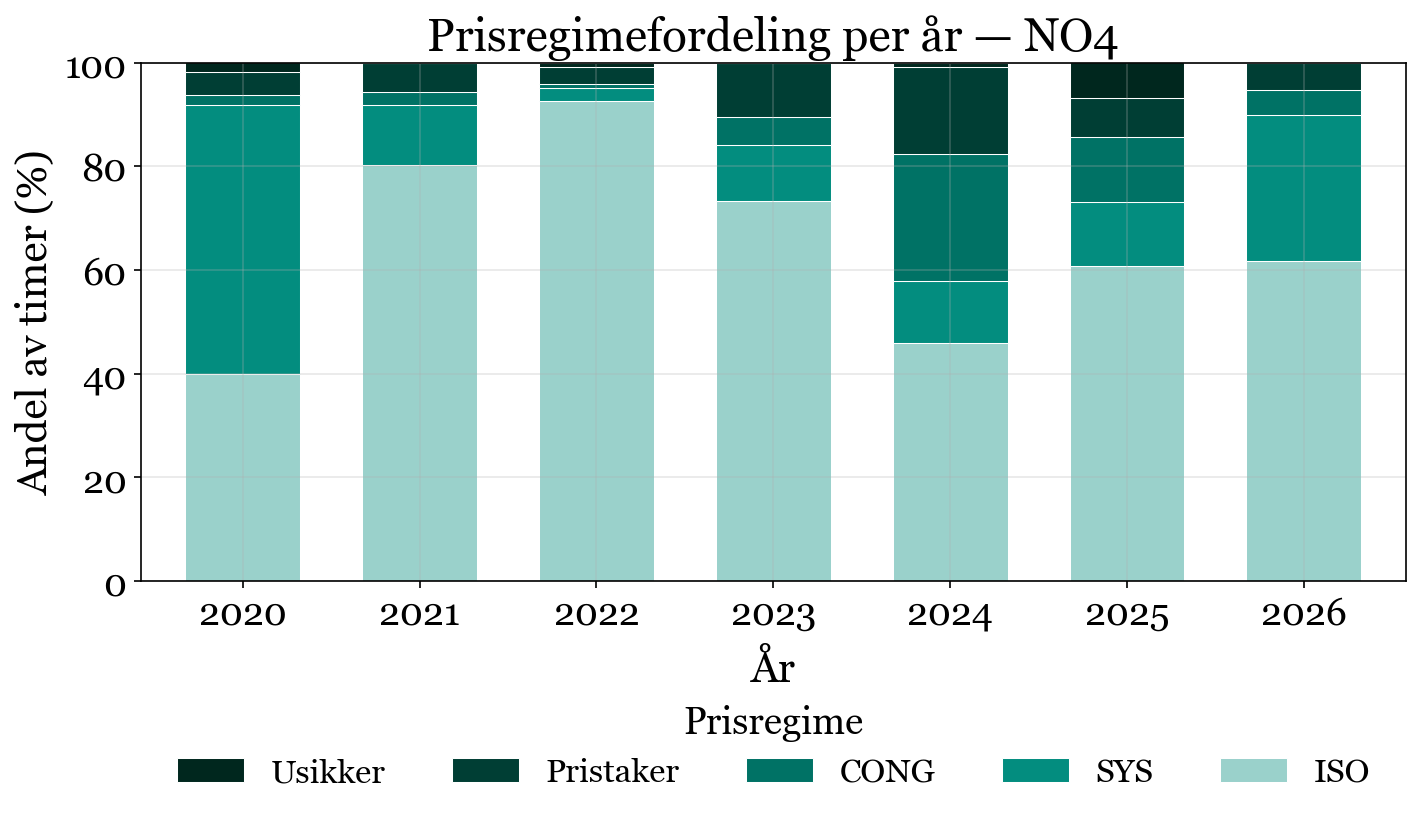

Lagret: ../figures/notebook/01/regime_per_year.pdf


In [12]:
# Figur: regimeandeler per år (stablet søylediagram)
SEC3_DIR = FIG_DIR + "01/"
os.makedirs(SEC3_DIR, exist_ok=True)

cols_plot = [c for c in STACK_ORDER if c in regime_by_year_pct.columns]
colors = [STACK_COLORS[c] for c in cols_plot]

plot_df = regime_by_year_pct[cols_plot].rename(columns=REGIME_LABELS_NO)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(
    kind="bar", stacked=True, ax=ax,
    color=colors, width=0.65, edgecolor="white", linewidth=0.5,
)
ax.set_xlabel("År", labelpad=8)
ax.set_ylabel("Andel av timer (%)")
ax.set_title("Prisregimefordeling per år — NO4")
ax.set_xticklabels(regime_by_year_pct.index, rotation=0)
ax.set_ylim(0, 100)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title="Prisregime", ncol=5, frameon=False,
          bbox_to_anchor=(0.5, -0.18), loc="upper center", fontsize=16)

plt.tight_layout()
plt.savefig(SEC3_DIR + "regime_per_year.pdf", bbox_inches="tight")
plt.show()
print("Lagret:", SEC3_DIR + "regime_per_year.pdf")

## 4. Lagre til intermediate/

In [13]:
# Lagre prosessert DataFrame og scaler
df.to_parquet(INTERMEDIATE_DIR + "df_processed.parquet")

with open(INTERMEDIATE_DIR + "scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "info": scaler_info}, f)

print(f"Lagret df_processed.parquet: {len(df):,} rader × {len(df.columns)} kolonner")
print(f"Lagret scaler.pkl")
print(f"\nKolonner i df_processed:")
for c in df.columns:
    print(f"  {c}")

Lagret df_processed.parquet: 53,394 rader × 41 kolonner
Lagret scaler.pkl

Kolonner i df_processed:
  price_FI
  price_NO3
  price_NO4
  price_SE1
  price_SE2
  system_price
  flow_NO4_FI
  flow_FI_NO4
  flow_NO4_NO3
  flow_NO3_NO4
  flow_NO4_SE1
  flow_SE1_NO4
  flow_NO4_SE2
  flow_SE2_NO4
  cons_FI
  cons_NO3
  cons_NO4
  cons_SE1
  prod_fossil_NO4
  prod_hydro_ror_NO4
  prod_hydro_res_NO4
  prod_other_renew_NO4
  prod_wind_NO4
  prod_total_NO4
  net_position
  fill_rate
  temp_NO4
  precip_NO4
  hour
  month
  weekday
  season
  is_weekend
  neg_price
  cons_c
  fill_c
  wind_c
  net_pos_c
  cons_x_fill_c
  regime
  regime_group
